In [23]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['font.size'] = 20
ecolor = list(mcolors.TABLEAU_COLORS)

BOHR_TO_ANG = 0.52917721092
HA_TO_EV = 27.211386245

In [32]:
class DFTHUB:
    def __init__(self, target_dir, nkpts, nband, hspts, hspts_label):
        self.target_dir = target_dir
        self.target_mat = self.target_dir.split('_')[0].split('-')[0]
        self.target_dir_full = f'{os.getcwd()}/data/{self.target_dir}'

        self.nkpts = nkpts
        self.nband = nband
        self.hspts = hspts
        self.hspts_label = hspts_label

    def show_etot(self):
        fin, acell, etot = 0, [], []
        with open(f'{self.target_dir_full}/cell_.abo', 'r') as f:
            for line in f:
                if fin:
                    if 'acell' in line: acell.append(line.split()[1])
                    if 'etotal' in line: etot.append(line.split()[1])
                elif 'END DATASET' in line: fin = 1
        data = np.column_stack((acell[:-1], etot)).astype(float)
        data = np.column_stack((data[:, 0] * BOHR_TO_ANG, data[:, 1] * HA_TO_EV))

        fig, ax = plt.subplots(figsize=(8, 6), dpi=120, tight_layout=True)
        ax.plot(data[:, 0], data[:, 1], '.-')
        ax.axvline(data[np.argmin(data[:, 1]), 0], color='r', ls='--')
        ax.set_xticks(data[:, 0], [f'{x:.2f}' for x in data[:, 0]], rotation=60, ha='center')
        ax.set_xlabel(r'$d$ (Å)')
        ax.set_ylabel(r'$E_{\mathrm{tot}}$ (eV)')

        fig.savefig(f'fig/{self.target_dir}_cell_etot.svg')
        plt.show()

    def show_fatband(self, l_list=[-1], s_list=[1], ylim=(-9, 9), plot_dos=False, xlim_dos=(0, 7)):
        fn_head = f'band_o_DS2_FATBANDS_at0001_{self.target_mat}'
        if sum(l_list) < 0:
            fn_list = sorted([fn for fn in os.listdir(self.target_dir_full) if re.search(fn_head, fn)])
        else:
            fn_list = [f'{fn_head}_is{s:d}_l{l:04d}' for s in s_list for l in l_list]
        print(*fn_list, sep='\n', end='\n\n')

        band = []
        for fn in fn_list:
            with open(f'{self.target_dir_full}/{fn}', 'r') as f:
                band_l = []
                for line in f:
                    if line.strip() and not re.match(r'[#@&]', line):
                        band_l.append([float(v) for v in line.strip().split()])
                band.append(np.split(np.array(band_l), self.nband))

        if plot_dos:
            fig, ax = plt.subplots(1, 2, figsize=(8, 6), width_ratios=(3, 1), dpi=120, tight_layout=True)
            ax0 = ax[0]
            
            dos = []
            with open(f'{self.target_dir_full}/band_o_DS3_DOS_AT0001', 'r') as f:
            	for line in f:
            		if 'Fermi energy' in line: fermi = float(re.search(r'[-]?\d+\.\d+', line).group())
            		if line.strip() and not re.match(r'[#@&]', line):
            			dos.append([float(v) for v in line.strip().split()])
            dos = np.split(np.array(dos), len(s_list))

            label = [r'$s\uparrow$', r'$s\downarrow$'] if len(s_list) == 2 else [r'$s$']
            color = ['r', 'b']
            for s, dos_s in enumerate(dos):
                ax[1].plot(dos_s[:, 1], (dos_s[:, 0] - fermi)*HA_TO_EV, label=label[s], c=color[s])
            ax[1].axhline(0, lw=2, ls='--', color='k', alpha=0.2)

            ax[1].set_xlim(*xlim_dos)
            ax[1].set_ylim(*ylim)
            ax[1].get_yaxis().set_visible(False)
            ax[1].legend(fontsize='x-small', loc='upper right')
        else:
            fig, ax = plt.subplots(figsize=(8, 6), dpi=120, tight_layout=True)
            ax0 = ax

        w, alpha = 6, 0.7
        for l in l_list:
            for i, b in enumerate(band[l]):
                ax0.errorbar(b[:, 0], b[:, 1], b[:, 2]*w, c='k', ecolor=ecolor[l], alpha=alpha, label=None if i else rf'$l = {l}$')
                #if b[0, 1] > ylim[0] and b[0, 1] < ylim[1]: ax0.text(b[0, 0]+1, b[0, 1]+0.1, rf'{i+1}$\uparrow$', fontsize='xx-small')
        ax0.axhline(0, lw=2, ls='--', color='k', alpha=0.2)
    
        for p in self.hspts:
            ax0.axvline(p, lw=2, color='k', alpha=0.2)
        ax0.set_xticks(self.hspts, labels=self.hspts_label)
        
        ax0.set_xlim(0, self.nkpts-1)
        ax0.set_ylim(*ylim)
        ax0.set_ylabel(r'$E - E_{F}$')
        ax0.legend(fontsize='x-small', loc='upper right')

        fig.savefig(f'fig/{self.target_dir}_{fn_head if l < 0 else fn_list[0]}.svg')
        plt.show()

    def show_wann(self, ylim=(-9, 9), is_sppol=False):
        fn_abo = f'wann_.abo'
        if is_sppol:
            fn_wan_list = ['w90_up_band.dat', 'w90_down_band.dat']
            fn_dft_list = [f'band_o_DS2_FATBANDS_at0001_{self.target_mat}_is1_l0000',
                           f'band_o_DS2_FATBANDS_at0001_{self.target_mat}_is2_l0000']
            Ns = 2
        else:
            fn_wan_list = ['w90_band.dat']
            fn_dft_list = [f'band_o_DS2_FATBANDS_at0001_{self.target_mat}_is1_l0000']
            Ns = 1

        with open(f'{self.target_dir_full}/{fn_abo}', 'r') as f:
            for line in f:
                if 'Fermi' in line: fermi = float(re.search(r'[-]?\d+\.\d+', line).group()) * HA_TO_EV

        band_wan = []
        for fn_wan in fn_wan_list:
            with open(f'{self.target_dir_full}/{fn_wan}', 'r') as f:
                band_wan_s = []
                for line in f:
                    if line.strip():
                        band_wan_s.append([float(v) for v in line.strip().split()[:2]])
            band_wan.append(np.array(band_wan_s))

        band_dft = []
        for fn_dft in fn_dft_list:
            with open(f'{self.target_dir_full}/{fn_dft}', 'r') as f:
                band_dft_s = []
                for line in f:
                    if line.strip() and not re.match(r'[#@&]', line):
                        band_dft_s.append([float(v) for v in line.strip().split()])
                band_dft.append(np.split(np.array(band_dft_s), self.nband))

        fig, ax = plt.subplots(figsize=(8, 6), dpi=120, tight_layout=True)
        for s in range(Ns):
            ax.scatter(np.arange(len(band_wan[s])), band_wan[s][:, 1]-fermi, color='r', label=None if s else 'wann')
            for b in band_dft[s]:
                ax.plot(b[:, 0], b[:, 1], c='k')
        ax.axhline(0, lw=2, ls='--', color='k', alpha=0.2)

        for p in self.hspts:
            ax.axvline(p, lw=2, color='k', alpha=0.2)
        ax.set_xticks(self.hspts, labels=self.hspts_label)

        ax.set_xlim(0, self.nkpts-1)
        ax.set_ylim(*ylim)
        ax.set_ylabel(r'$E - E_{F}$')
        ax.legend(fontsize='x-small', loc='upper right')

        fig.savefig(f'fig/{self.target_dir}_wann_band.svg')
        plt.show()

band_o_DS2_FATBANDS_at0001_Li_is1_l0000
band_o_DS2_FATBANDS_at0001_Li_is1_l0001
band_o_DS2_FATBANDS_at0001_Li_is2_l0000
band_o_DS2_FATBANDS_at0001_Li_is2_l0001



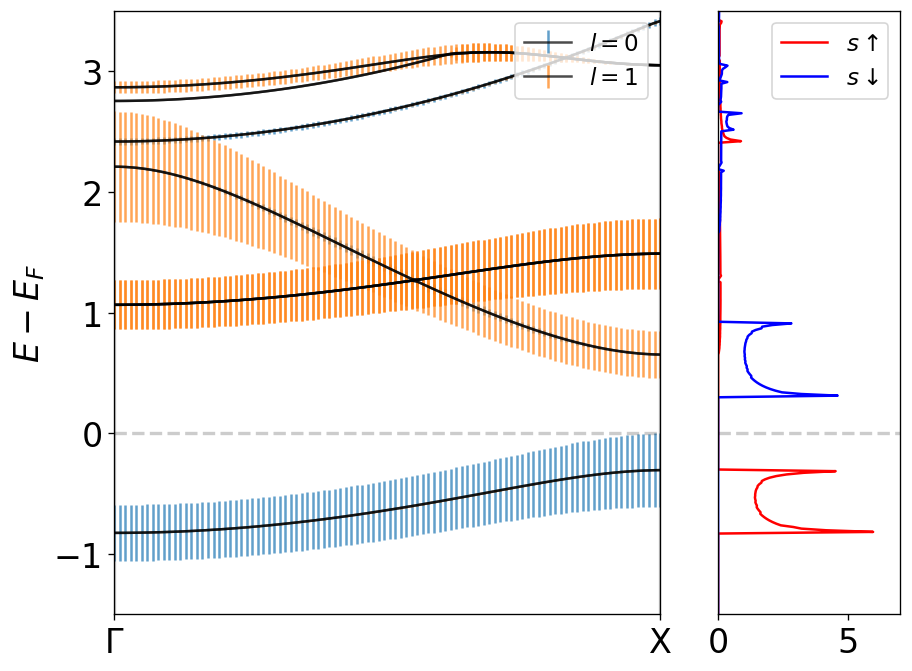

In [29]:
Li = DFTHUB('Li_init', nkpts=100, nband=8, hspts=[0, 99], hspts_label=[r'$\Gamma$', 'X'])
#Li.show_etot()
Li.show_fatband(l_list=[0, 1], s_list=[1, 2], ylim=(-1.5, 3.5), plot_dos=True)
#Li.show_wann(ylim=(-1.5, 3.5), is_sppol=True)

band_o_DS2_FATBANDS_at0001_Li_is1_l0000
band_o_DS2_FATBANDS_at0001_Li_is1_l0001



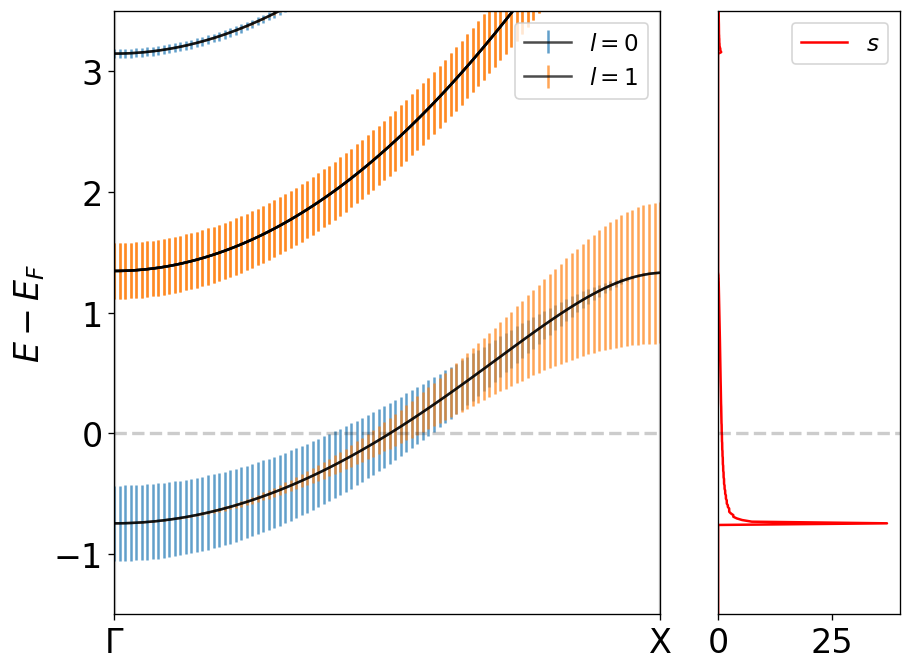

In [30]:
Li_a1 = DFTHUB('Li-a1_init', nkpts=100, nband=8, hspts=[0, 99], hspts_label=[r'$\Gamma$', 'X'])
#Li_a1.show_etot()
Li_a1.show_fatband(l_list=[0, 1], s_list=[1], ylim=(-1.5, 3.5), plot_dos=True, xlim_dos=(0, 40))
#Li_a1.show_wann(ylim=(-1.5, 3.5), is_sppol=False)

band_o_DS2_FATBANDS_at0001_Li_is1_l0000
band_o_DS2_FATBANDS_at0001_Li_is1_l0001



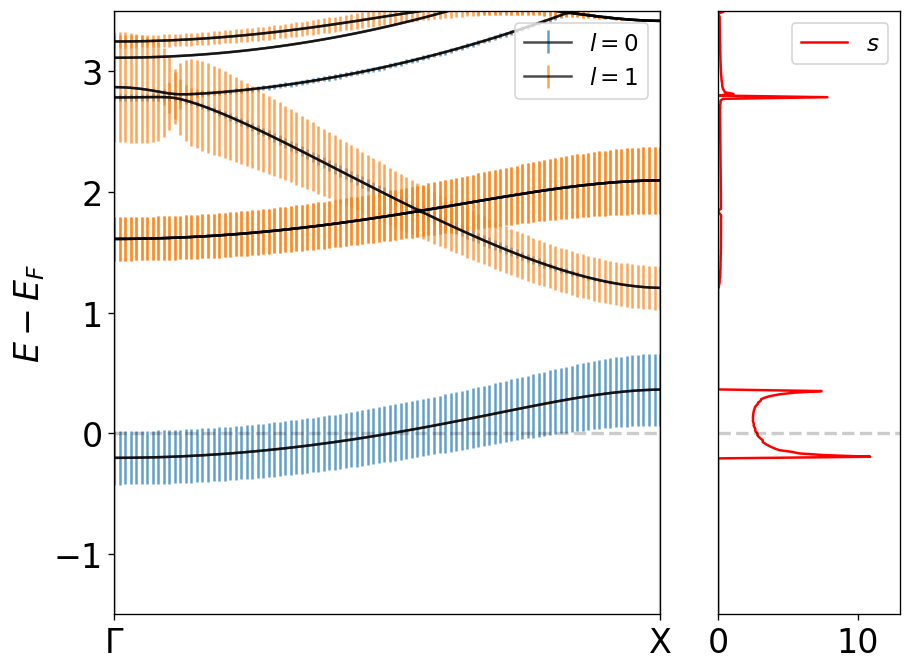

In [31]:
Li_a2 = DFTHUB('Li-a2_init', nkpts=100, nband=8, hspts=[0, 99], hspts_label=[r'$\Gamma$', 'X'])
#Li_a2.show_etot()
Li_a2.show_fatband(l_list=[0, 1], s_list=[1], ylim=(-1.5, 3.5), plot_dos=True, xlim_dos=(0, 13))
#Li_a2.show_wann(ylim=(-1.5, 3.5), is_sppol=False)